# Notebook 1 — The synthesis loop (and what “good synth” means)

**Workshop path:** [Notebook 0](00_flight_precheck.ipynb) → optional [0.5](00.5_method_comparison.ipynb) → **this notebook** → [2](02_batch_dataset_generation.ipynb) → [3](03_training_and_evaluation.ipynb).

**Recommended defaults:** `HARDWARE` from NB0 · generator **`instruct` (Klein)** · Vector API **judge**.

Two threads run together:

1. **Pipeline** — every synthesis loop needs `load → edit → annotate → judge → retry`.
2. **Quality** — *fidelity*, *novelty*, and *usability* — and how each step gauges them.

> **Judge** in this bootcamp means the **API VLM plus every hard gate** before accept (boxes, placement, VLM fidelity, CLIP embedding safe-zone). Soft scores alone do not ship data.


---
## F1 — Pipeline at a glance

```text
 real photo → LOAD → EDIT → ANNOTATE → JUDGE (VLM + gates) → accept
                                              │
                                              └─ retry (new variation) / reject
```

See also [docs/figures.md](../docs/figures.md). Generator choice was the topic of Notebook 0.5; here we wire **everything around** the edit.


---
## What makes a good synthetic sample?

| Idea | Meaning | How we gauge it in this notebook |
|------|---------|----------------------------------|
| **Fidelity** | Looks like real data / real class instances | VLM `global_fidelity` / `object_fidelity` vs real refs [[7]](../docs/citations.md); CLIP KNN vs **real** bank [[8]](../docs/citations.md) |
| **Novelty** | Useful new signal, not a near-copy | Prompt **variations**; CLIP KNN vs **real ∪ accepted synth** (`max_neighbor_sim`) |
| **Usability** | Trainable for detection | Open-vocab **boxes**; placement gates; `edge_case_present` + overall threshold |

### F2 — Embedding safe-zone (intuition)

```text
        far from real  →  ✗ fidelity fail
        ─────────────────────────────────
              ✓ safe zone
        ─────────────────────────────────
        near-dupe of bank  →  ✗ novelty fail
```

Tunables live in `configs/default/judge.yaml` → `embedding_gate` and `fidelity_threshold`.


---
## 0. Setup

Prefer Notebook 0 for env + samples. Then:


In [1]:
from pathlib import Path

from aieng.syn_data.image.bootstrap import bootstrap_project_root
from aieng.syn_data.image.config import load_env


PROJECT_ROOT = bootstrap_project_root()
load_env(PROJECT_ROOT)
print("PROJECT_ROOT =", PROJECT_ROOT)


/home/coder/synthetic-data-bootcamp/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_ROOT = /home/coder/synthetic-data-bootcamp/implementations/edge_case_image_generation


---
## 1. LOAD — knobs + a real seed

**Quality link:** starting from a real photo anchors **domain fidelity** (camera, lighting, clutter) better than pure text-to-image for ADAS-style data.

| Knob | What it does |
|------|----------------|
| `HARDWARE` | `cpu` / `gpu_l4` / `gpu_l4x2` — which checkpoints Hydra loads |
| `METHOD_BY_ANOMALY` | Per-class editor (`instruct` recommended) |
| `SCENE_INDEX` | Which `scene_*` seed to edit (try another if Klein pastes on the hood) |
| `MAX_RETRIES` | Judge-driven re-edits with the next prompt variation |

Anomaly YAML playbook (prompts, masks, gates, variations): [docs/anomaly_authoring.md](../docs/anomaly_authoring.md).


/home/coder/synthetic-data-bootcamp/.venv/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.


Dataset=mapillary_vistas  Hardware=gpu_l4
Generator=black-forest-labs/FLUX.2-klein-4B
Judge=api/gemini-3-flash-preview
  traffic_cone     → instruct (Klein instruct (small local))
  trash_bin        → instruct (Klein instruct (small local))
Seed: scene_-_prubhCd03M0BLOHOGGOA (index 0/319)


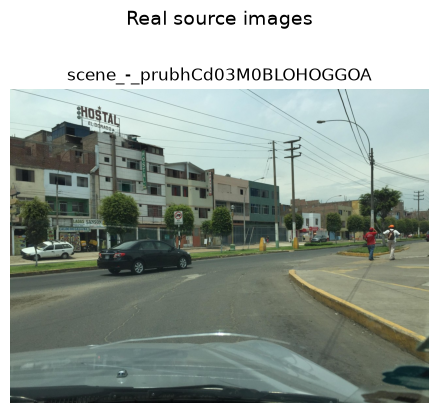

In [2]:
import os


os.environ.setdefault("HF_HUB_DISABLE_XET", "1")

from pathlib import Path

from aieng.syn_data.image.compare_methods import METHOD_SPECS, PIPELINE_METHODS
from aieng.syn_data.image.config import load_config
from aieng.syn_data.image.data import (
    ImageSample,
    get_data_source_info,
    list_sample_images,
    prepare_sample_images,
)
from aieng.syn_data.image.pipeline import resolve_method_map
from aieng.syn_data.image.viz import show_samples
from PIL import Image


DATASET = "mapillary_vistas"
HARDWARE = "gpu_l4"  # from Notebook 0

METHOD_BY_ANOMALY = {
    "traffic_cone": "instruct",
    "trash_bin": "instruct",
}
MAX_RETRIES = 2
SCENE_INDEX = 0

cfg = load_config(
    start=PROJECT_ROOT,
    overrides=[f"dataset_name={DATASET}", f"hardware={HARDWARE}"],
)
info = get_data_source_info(cfg)
prepare_sample_images(cfg=cfg)
samples_dir = Path(cfg.paths.samples_dir)

workshop = list(METHOD_BY_ANOMALY) or list(cfg.dataset.workshop_anomalies)
method_map = resolve_method_map(METHOD_BY_ANOMALY, workshop, cfg=cfg)
for _aid, method in method_map.items():
    if method not in PIPELINE_METHODS:
        raise ValueError(f"{method!r} is NB0.5-only; use one of {PIPELINE_METHODS}")

print(f"Dataset={cfg.dataset_name}  Hardware={cfg.hardware.name}")
print(f"Generator={cfg.generation.instruct_model_id}")
print(f"Judge={cfg.judge.backend}/{cfg.judge.model_id}")
for aid, method in method_map.items():
    print(f"  {aid:16s} → {method} ({METHOD_SPECS[method].title})")

scene_paths = sorted(p for p in list_sample_images(samples_dir) if p.stem.startswith("scene_"))
if not scene_paths:
    raise RuntimeError(f"No scene_* in {samples_dir} — run Notebook 0 data cell")
scene_i = int(SCENE_INDEX) % len(scene_paths)
sample = ImageSample(
    path=scene_paths[scene_i],
    image=Image.open(scene_paths[scene_i]).convert("RGB"),
    name=scene_paths[scene_i].stem,
)
print(f"Seed: {sample.name} (index {scene_i}/{len(scene_paths) - 1})")
show_samples([sample], ncol=1, figsize=(8, 4));

---
## 2. EDIT — insert the rare condition

**Quality link:** prompt **variations** (size, color, side, placement, …) are the first **novelty** lever; a bad edit destroys **fidelity** (hood paste, style drift).

Method details: Notebook 0.5. Here we run the production default (`instruct`). Depth/seg still load because some methods/masks use them.


Loading weights: 100%|██████████| 644/644 [00:00<00:00, 27172.18it/s]


traffic_cone  via  instruct


100%|██████████| 4/4 [00:09<00:00,  2.49s/it]


variation: {'size': 'medium', 'color': 'faded orange', 'stripe': 'with a white reflective stripe', 'side': 'on the right side of the lane', 'placement': 'further down the open asphalt lane ahead', 'scale_hint': 'correctly scaled versus nearby cars'}
prompt: Add one medium faded orange traffic cone with a white reflective stripe standing upright on the asphalt road surface on the right side of the lane, further down the open asphalt lane ahead, correctly scaled versus nearby cars, base resting on the pavement with a natural contact shadow. Place it clearly ON THE ROAD beyond the camera-car hood — never on the hood, windshield, dashboard, or bumper. Do not recolor cars or buildings.
{'image': PosixPath('/home/coder/synthetic-data-bootcamp/implementations/edge_case_image_generation/outputs/mapillary_vistas/nb1/traffic_cone/generated/scene_-_prubhCd03M0BLOHOGGOA_traffic_cone.png'), 'metadata': PosixPath('/home/coder/synthetic-data-bootcamp/implementations/edge_case_image_generation/outputs

100%|██████████| 4/4 [00:09<00:00,  2.28s/it]


variation: {'size': 'large', 'material': 'plastic', 'color': 'green', 'side': 'on the left side of the frame', 'placement': 'near the curb on the asphalt edge'}
prompt: Add one large green plastic trash bin standing upright on the left side of the frame, near the curb on the asphalt edge, correctly scaled versus nearby cars and lane features, with natural contact shadow and matching scene lighting. Keep the rest of the street photo unchanged.
{'image': PosixPath('/home/coder/synthetic-data-bootcamp/implementations/edge_case_image_generation/outputs/mapillary_vistas/nb1/trash_bin/generated/scene_-_prubhCd03M0BLOHOGGOA_trash_bin.png'), 'metadata': PosixPath('/home/coder/synthetic-data-bootcamp/implementations/edge_case_image_generation/outputs/mapillary_vistas/nb1/trash_bin/generated/scene_-_prubhCd03M0BLOHOGGOA_trash_bin.txt')}


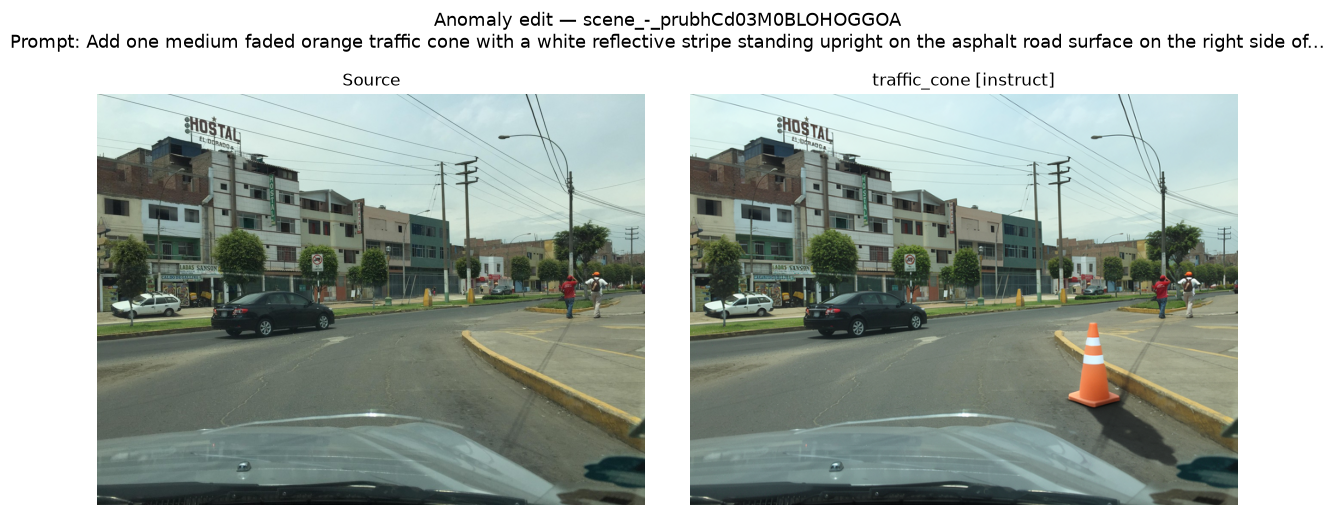

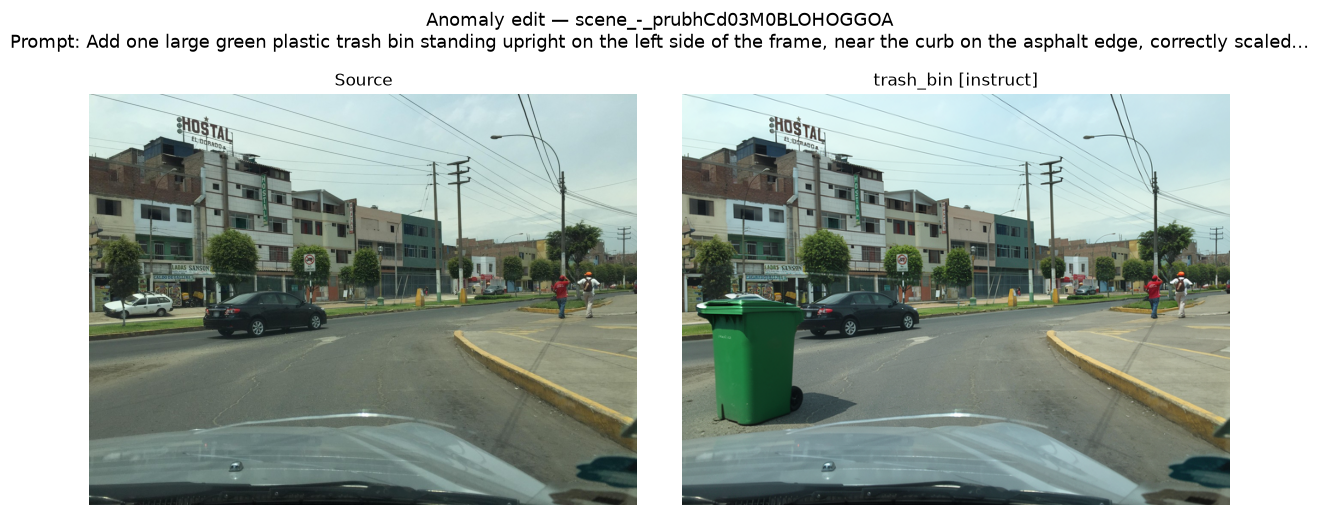

In [3]:
from aieng.syn_data.image.compare_methods import MethodComparer
from aieng.syn_data.image.conditioning import DepthEstimator, Segmenter
from aieng.syn_data.image.pipeline import synthesize_one
from aieng.syn_data.image.viz import save_generation_artifact, show_generation_result


depth_model = DepthEstimator.from_config(cfg)
segmenter = Segmenter.from_config(cfg)
comparer = MethodComparer.from_config(cfg)
depth = depth_model.predict(sample.image)
seg = segmenter.predict(sample.image)
output_dir = Path(cfg.paths.outputs_dir)
results = {}

for anomaly_id, method in method_map.items():
    print("=" * 60)
    print(f"{anomaly_id}  via  {method}")
    syn = synthesize_one(
        sample.image,
        anomaly_id=anomaly_id,
        method=method,
        cfg=cfg,
        comparer=comparer,
        depth=depth,
        segmentation=seg,
        project_root=PROJECT_ROOT,
        variation_index=0,
    )
    results[anomaly_id] = syn
    if syn.generated.variation:
        print("variation:", syn.generated.variation)
    print("prompt:", syn.generated.prompt)
    show_generation_result(sample, syn.generated)
    print(save_generation_artifact(sample, syn.generated, output_dir / "nb1" / anomaly_id))

---
## 3. ANNOTATE — boxes for usability

**Quality link:** detection training needs **boxes**. We use open-vocab YOLO-World [[6]](../docs/citations.md) with per-anomaly query phrases, plus edit-mask fallback in the batch path.

No box → cannot accept for the detector export (hard **usability** gate in NB2).


detector: yolov8s-worldv2.pt
  queries[traffic_cone]: ['traffic cone', 'orange cone', 'cone', 'road']  conf=0.2


/home/coder/synthetic-data-bootcamp/.venv/lib/python3.12/site-packages/torch/jit/_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(


/home/coder/synthetic-data-bootcamp/implementations/edge_case_image_generation/outputs/mapillary_vistas/nb1/annotations/scene_-_prubhCd03M0BLOHOGGOA_traffic_cone_annotated.png
  queries[trash_bin]: ['trash can', 'garbage bin', 'waste bin', 'dumpster', 'road']  conf=0.2
/home/coder/synthetic-data-bootcamp/implementations/edge_case_image_generation/outputs/mapillary_vistas/nb1/annotations/scene_-_prubhCd03M0BLOHOGGOA_trash_bin_annotated.png


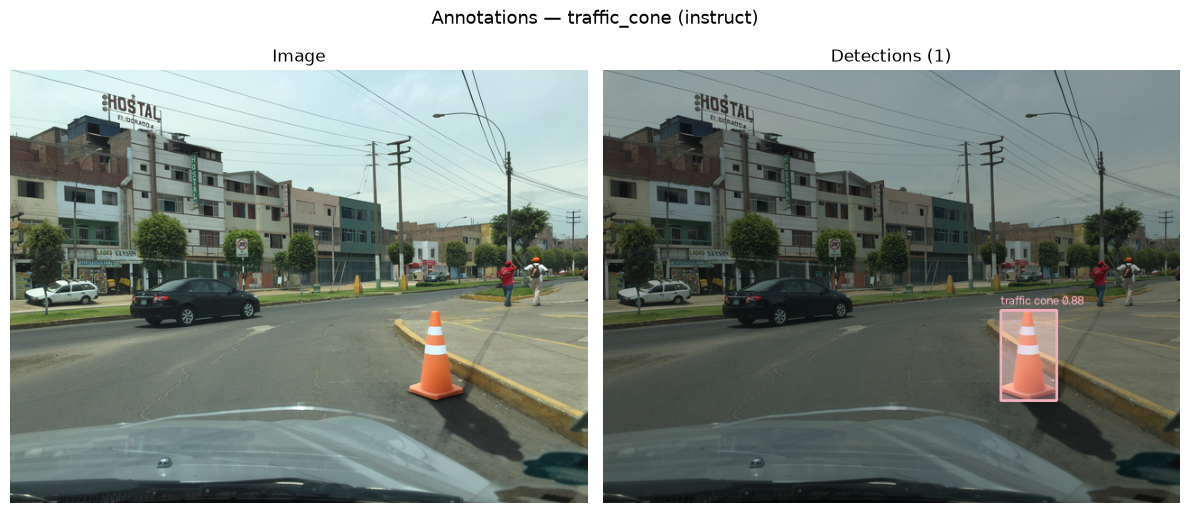

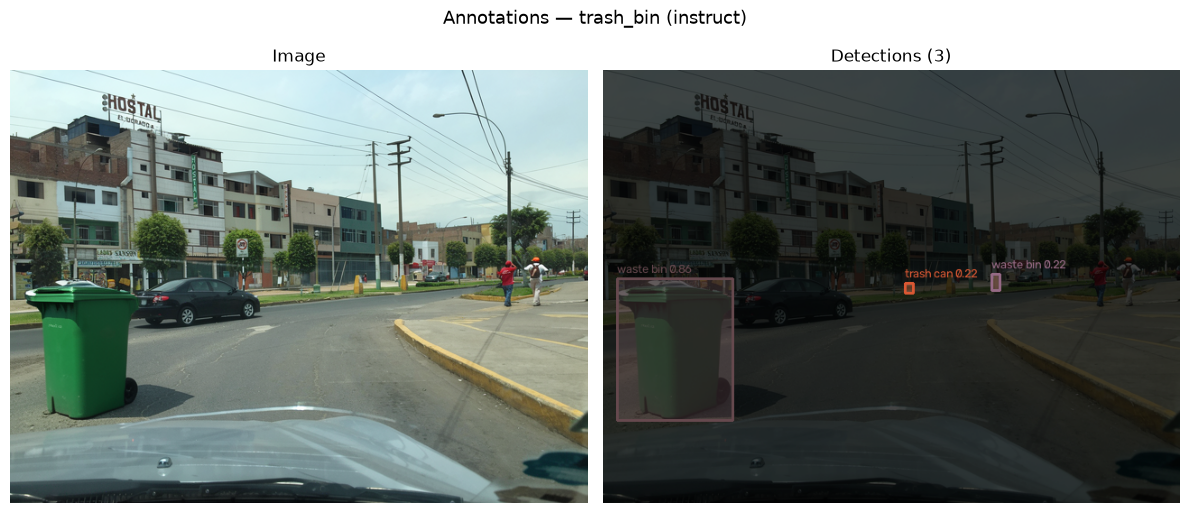

In [4]:
from aieng.syn_data.image.annotation import OpenVocabAnnotator
from aieng.syn_data.image.config import load_anomaly
from aieng.syn_data.image.viz import save_annotation_artifact, show_annotation_result


def annotate_anomaly(syn, anomaly_id: str, annotator: OpenVocabAnnotator):
    """Annotate one synthesized anomaly image."""
    anomaly_cfg = load_anomaly(dataset, anomaly_id, start=PROJECT_ROOT)
    anomaly_classes = list(anomaly_cfg.get("annotation_classes", []))
    classes = list(dict.fromkeys([*(anomaly_classes or base_classes)]))
    conf = anomaly_cfg.get("annotation_conf")
    conf = float(conf) if conf is not None else None
    print(f"  queries[{anomaly_id}]: {classes}  conf={conf or cfg.annotation.conf}")
    return annotator.annotate(syn.generated.image, classes=classes, conf=conf)


annotator = OpenVocabAnnotator.from_config(cfg)
base_classes = list(cfg.annotation.classes)
annotations = {}
dataset = str(cfg.dataset_name)
print("detector:", cfg.annotation.detector_model)

for anomaly_id, syn in results.items():
    print("=" * 60)
    annotation = annotate_anomaly(syn, anomaly_id, annotator)
    annotations[anomaly_id] = annotation
    show_annotation_result(
        syn.generated.image,
        annotation,
        title=f"Annotations — {anomaly_id} ({syn.method})",
    )
    print(save_annotation_artifact(f"{sample.name}_{anomaly_id}", annotation, output_dir / "nb1"))

---
## 4. JUDGE — VLM + gates (including Slice C)
> **Runtime ~1.5mins on `gpu_l4x2`:** 

Unload the edit stack first (VRAM). The judge step:

1. **API VLM** scores faithfulness, plausibility, boxes, `edge_case_present`, overall [[7]](../docs/citations.md).
2. **Reference fidelity (slice B)** — real same-class photos (+ crops); hard retry if `global_fidelity` / `object_fidelity` &lt; `fidelity_threshold`.
3. **Embedding safe-zone (slice C)** — CLIP KNN [[8]](../docs/citations.md): close enough to **real**, not too close to **real ∪ accepted**.
4. **Box / placement gates** (stronger in NB2) — usability.

Decision: `accept` / `retry` / `reject`. On retry we re-edit with the **next variation** + new seed.


Judge api/gemini-3-flash-preview  threshold=7.0
Fidelity refs full=2 crops=1 fid_threshold=5.5
Embed gate enabled=True min_real=0.58 max_nn=0.94

→ judging traffic_cone attempt=0 …


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 28534.63it/s]


traffic_cone → retry (6.0)
  fidelity  global=7.0  object=6.0
  embed     real=0.824  local=0.9160730242729187  neighbor=0.823539674282074
Cone is correctly placed on road, though overly vibrant and auto-annotation is misplaced.
/home/coder/synthetic-data-bootcamp/implementations/edge_case_image_generation/outputs/mapillary_vistas/nb1/judgments/scene_-_prubhCd03M0BLOHOGGOA_traffic_cone_a0_judge.json
  retrying with variation_index=1 …


100%|██████████| 4/4 [00:09<00:00,  2.33s/it]


  queries[traffic_cone]: ['traffic cone', 'orange cone', 'cone', 'road']  conf=0.2

→ judging traffic_cone attempt=1 …


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 28153.49it/s]


traffic_cone → accept (7.0)
  fidelity  global=7.0  object=6.0
  embed     real=0.798  local=0.9176740050315857  neighbor=0.7981593608856201
The cone is well-integrated and realistic, though it includes stripes despite the negative prompt instruction.
/home/coder/synthetic-data-bootcamp/implementations/edge_case_image_generation/outputs/mapillary_vistas/nb1/judgments/scene_-_prubhCd03M0BLOHOGGOA_traffic_cone_a1_judge.json

→ judging trash_bin attempt=0 …
trash_bin → accept (7.0)
  fidelity  global=7.0  object=6.0
  embed     real=0.796  local=None  neighbor=0.7960619330406189
Green bin correctly positioned with natural lighting integration.
/home/coder/synthetic-data-bootcamp/implementations/edge_case_image_generation/outputs/mapillary_vistas/nb1/judgments/scene_-_prubhCd03M0BLOHOGGOA_trash_bin_a0_judge.json
Acceptance: 2/2
  traffic_cone     accept   method=instruct
  trash_bin        accept   method=instruct


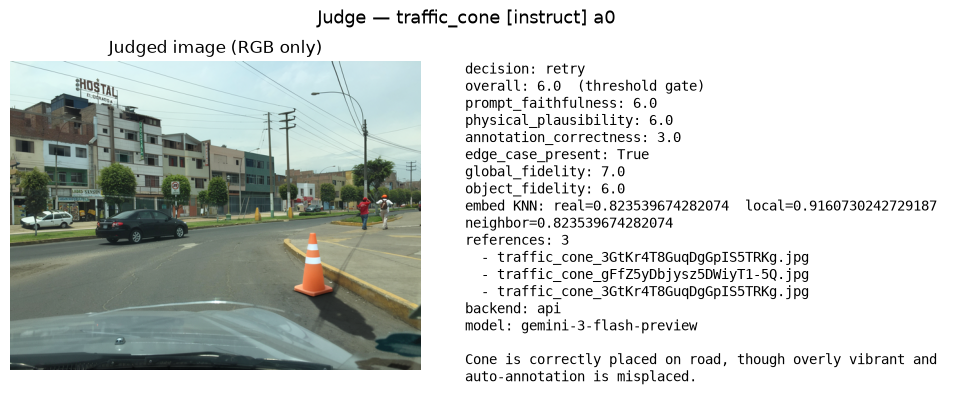

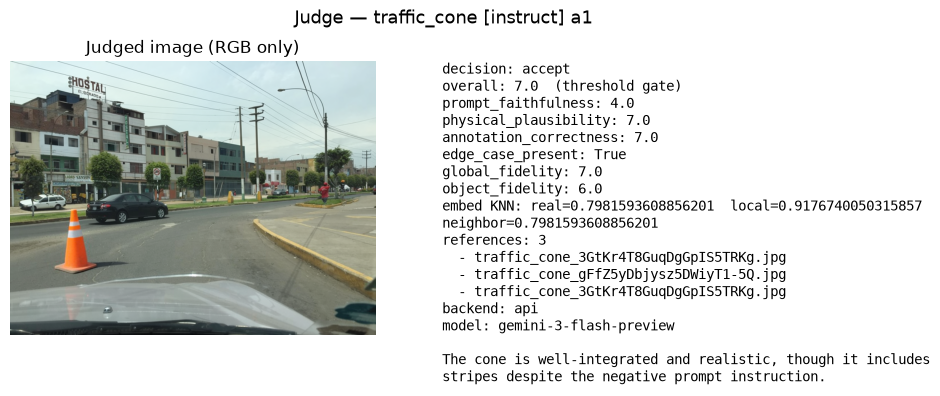

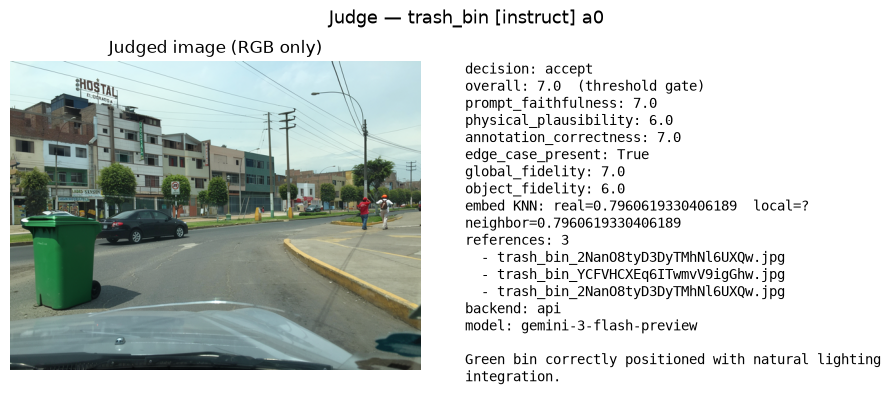

In [5]:
import gc

import torch
from aieng.syn_data.image.judge import VLMJudge, summarize_annotations
from aieng.syn_data.image.viz import save_judge_artifact, show_judge_result


def _unload(*names: str) -> None:
    for name in names:
        obj = globals().get(name)
        if obj is not None and hasattr(obj, "unload"):
            obj.unload()
        globals()[name] = None
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


_unload("comparer", "annotator", "depth_model", "segmenter")
if "results" not in globals() or not results:
    raise RuntimeError("No `results` — re-run the EDIT cell first.")

judge = VLMJudge.from_config(cfg)
source_hint = str(cfg.dataset.get("source_hint", "a real photograph"))
emb = dict(cfg.judge.get("embedding_gate") or {})
print(f"Judge {judge.backend}/{judge.model_id}  threshold={judge.threshold}")
print(
    f"Fidelity refs full={judge.n_reference_full} crops={judge.n_reference_crops} "
    f"fid_threshold={judge.fidelity_threshold}",
)
print(
    f"Embed gate enabled={bool(emb.get('enabled', True))} "
    f"min_real={emb.get('min_real_sim_global', 0.58)} "
    f"max_nn={emb.get('max_neighbor_sim', 0.94)}",
)

judgments = {}
final_results = dict(results)

for anomaly_id, syn in list(results.items()):
    anomaly_cfg = load_anomaly(dataset, anomaly_id, start=PROJECT_ROOT)
    attempt = 0
    current = syn
    while True:
        print(f"\n→ judging {anomaly_id} attempt={attempt} …", flush=True)
        result = judge.judge(
            current.generated.image,
            prompt=current.generated.prompt,
            anomaly_id=anomaly_id,
            anomaly_name=str(anomaly_cfg.get("display_name", anomaly_id)),
            annotations_summary=summarize_annotations(annotations.get(anomaly_id)),
            source_hint=source_hint,
            exclude_stems={sample.name},
            edit_mask=getattr(current.generated, "edit_mask", None),
            annotation=annotations.get(anomaly_id),
        )
        print(f"{anomaly_id} → {result.decision} ({result.overall:.1f})")
        print(f"  fidelity  global={result.global_fidelity}  object={result.object_fidelity}")
        if result.embed_real_sim_global is not None:
            print(
                f"  embed     real={result.embed_real_sim_global:.3f}  "
                f"local={result.embed_real_sim_local}  neighbor={result.embed_neighbor_sim}"
                + (f"  ({result.embed_gate_reason})" if result.embed_gate_reason else ""),
            )
        show_judge_result(
            current.generated.image,
            result,
            title=f"Judge — {anomaly_id} [{current.method}] a{attempt}",
        )
        print(result.rationale)
        print(save_judge_artifact(f"{sample.name}_{anomaly_id}_a{attempt}", result, output_dir / "nb1"))

        if result.decision != "retry" or attempt >= MAX_RETRIES:
            if result.decision == "accept":
                judge.register_accepted_embedding(
                    anomaly_id,
                    current.generated.image,
                    path=f"nb1:{anomaly_id}:{sample.name}",
                )
            judgments[anomaly_id] = result
            final_results[anomaly_id] = current
            break

        attempt += 1
        print(f"  retrying with variation_index={attempt} …")
        _unload("judge")
        depth_model = DepthEstimator.from_config(cfg)
        segmenter = Segmenter.from_config(cfg)
        comparer = MethodComparer.from_config(cfg)
        annotator = OpenVocabAnnotator.from_config(cfg)
        depth = depth_model.predict(sample.image)
        seg = segmenter.predict(sample.image)
        current = synthesize_one(
            sample.image,
            anomaly_id=anomaly_id,
            method=method_map[anomaly_id],
            cfg=cfg,
            comparer=comparer,
            depth=depth,
            segmentation=seg,
            project_root=PROJECT_ROOT,
            seed_offset=attempt,
            variation_index=attempt,
        )
        annotations[anomaly_id] = annotate_anomaly(current, anomaly_id, annotator)
        results[anomaly_id] = current
        _unload("comparer", "annotator", "depth_model", "segmenter")
        judge = VLMJudge.from_config(cfg)

accepted = sum(1 for r in judgments.values() if r.decision == "accept")
print(f"Acceptance: {accepted}/{len(judgments)}")
for aid, r in judgments.items():
    print(f"  {aid:16s} {r.decision:7s}  method={method_map[aid]}")

---
## 5. Optional — embedding threshold lab

After a judge pass, inspect sims vs defaults. Tighten `min_real_sim_*` if junk accepts; loosen / raise `max_neighbor_sim` if everything near-dupes. Re-run the judge cell after editing `configs/default/judge.yaml`.


In [6]:
print("Current embedding_gate:")
for k, v in dict(cfg.judge.get("embedding_gate") or {}).items():
    print(f"  {k}: {v}")
print("\nLast judgments:")
for aid, r in judgments.items():
    print(f"  {aid:16s}  real={r.embed_real_sim_global}  neighbor={r.embed_neighbor_sim}  decision={r.decision}")

Current embedding_gate:
  enabled: True
  model_id: openai/clip-vit-base-patch32
  min_real_sim_global: 0.58
  min_real_sim_local: 0.52
  max_neighbor_sim: 0.94
  use_local: True
  fail_action: retry
  max_bank: 256
  max_side: 224

Last judgments:
  traffic_cone      real=0.7981593608856201  neighbor=0.7981593608856201  decision=accept
  trash_bin         real=0.7960619330406189  neighbor=0.7960619330406189  decision=accept


---
## Wrap-up

- You ran the full loop once; Notebook 2 scales it with load-once edit + parallel API judge.
- New class YAML? Use [anomaly_authoring.md](../docs/anomaly_authoring.md).
- Figures: [figures.md](../docs/figures.md) · Papers: [citations.md](../docs/citations.md) [[6]](../docs/citations.md)–[[8]](../docs/citations.md).
